In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import random
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Load Data

In [2]:
df = pd.read_csv("../data/DSA4262_Survey_Cleaned.csv")

### Feature Selection

In [24]:
# Demographics
demographics = ["Q1_Age"]  # numeric

# Smartphone usage behaviour (ordinal / Likert) Q4-Q34 and age
usage_num_cols = [
    "Q1_Age", "Q4_DailyPhoneTime_num", "Q5_CheckFrequency_num", "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num", "Q8_StopUseAtNight_num", "Q10_SocialMediaTime_num",
    "Q11_PhoneDuringMeals_num", "Q12_PhoneDuringWorkClass_num", "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num", "Q15_UseWhenBored_num", "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num", "Q18_PhoneInBed_num", "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num", "Q21_WakeToCheckPhone_num", "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num", "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num", "Q26_ConcentrationProblems_num", "Q27_PhysicalPain_num",
    "Q28_CannotStandWithoutPhone_num", "Q29_ImpatientWithoutPhone_num", "Q30_PhoneOnMyMind_num",
    "Q31_WontGiveUpPhone_num", "Q32_ConstantChecking_num", "Q33_UseLongerThanIntended_B_num",
    "Q34_OthersSayTooMuchUse_num"
]

# One-hot encoded demographics
onehot_cols = [col for col in df.columns if col.startswith("Q2_") or col.startswith("Q3_")]

# App usage binary columns
app_usage_cols = [
    "Q9_App_SocialMedia", "Q9_App_Messaging", "Q9_App_ProductivityStudy",
    "Q9_App_WebBrowsing", "Q9_App_VideoStreaming", "Q9_App_Gaming", "Q9_App_Shopping"
]

# Combine all feature columns
feature_cols = demographics + usage_num_cols + onehot_cols + app_usage_cols

### Prepare Train and Test Set

In [25]:
X = df[feature_cols]

# Classification target
y_class = df["PHQ9_10plus"]

# Regression target
y_reg = df["PHQ9_Total"]

# Classification
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Regression
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Feature columns used for modeling:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Feature columns used for modeling: 46
X_train shape: (400, 46)
X_test shape: (100, 46)


### Expand dataset size

In [26]:
target_size = 500
current_size = X.shape[0]

if current_size < target_size:
    n_to_add = target_size - current_size
    
    # sample with replacement
    df_synthetic = df.sample(n=n_to_add, replace=True, random_state=42).copy()
    
    # small perturbation for numeric features
    for col in usage_num_cols + ["Q1_Age"]:
        df_synthetic[col] = df_synthetic[col].apply(lambda x: max(0, min(x + random.choice([-1,0,1]), 10)))
    
    # combine original and synthetic
    df = pd.concat([df, df_synthetic], ignore_index=True)
    
    # recompute features and targets
    X = df[feature_cols]
    y_class = df["PHQ9_10plus"]
    y_reg = df["PHQ9_Total"]
    
    # train/test split
    X_train, X_test, y_train_class, y_test_class = train_test_split(
        X, y_class, test_size=0.2, random_state=42
    )
    _, _, y_train_reg, y_test_reg = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

print("Expanded dataset size:", df.shape)

Expanded dataset size: (500, 97)


## Task 1: Binary Classification

### Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train model
logreg.fit(X_train, y_train_class)

# Predict on test set
y_pred_class = logreg.predict(X_test)

# ===================== Evaluate =====================
acc = accuracy_score(y_test_class, y_pred_class)
print("Logistic Regression Test Accuracy:", acc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Logistic Regression Test Accuracy: 0.8

Confusion Matrix:
[[65  9]
 [11 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        74
           1       0.62      0.58      0.60        26

    accuracy                           0.80       100
   macro avg       0.74      0.73      0.73       100
weighted avg       0.80      0.80      0.80       100



## Random Forest

In [28]:
# Initialize model
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)

# Train model
rf_clf.fit(X_train, y_train_class)

# Predict on test set
y_pred_rf = rf_clf.predict(X_test)

# ===================== Evaluation =====================
acc_rf = accuracy_score(y_test_class, y_pred_rf)
print("Random Forest Test Accuracy:", acc_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_rf, zero_division=0))

Random Forest Test Accuracy: 0.94

Confusion Matrix:
[[74  0]
 [ 6 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        74
           1       1.00      0.77      0.87        26

    accuracy                           0.94       100
   macro avg       0.96      0.88      0.92       100
weighted avg       0.94      0.94      0.94       100



## Task 2: Regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

## Linear Regression

Linear Regression MSE: 10.750052690728761
Linear Regression R2: 0.45766789809610764


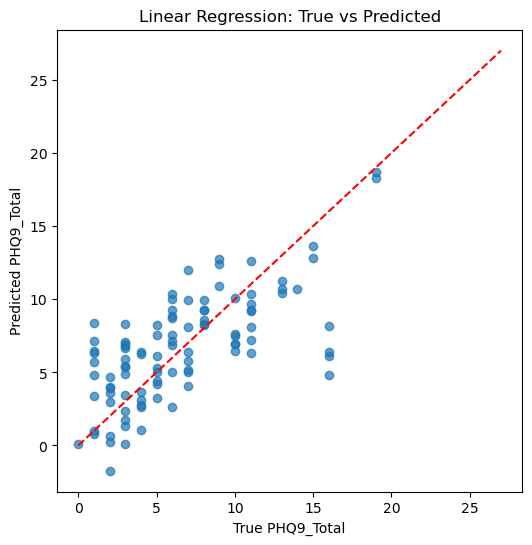

In [30]:
linreg = LinearRegression()
linreg.fit(X_train, y_train_reg)
y_pred_lin = linreg.predict(X_test)

# Evaluate
mse_lin = mean_squared_error(y_test_reg, y_pred_lin)
r2_lin = r2_score(y_test_reg, y_pred_lin)
print("Linear Regression MSE:", mse_lin)
print("Linear Regression R2:", r2_lin)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_lin, alpha=0.7)
plt.plot([0,27],[0,27], 'r--')  # y=x line
plt.xlabel("True PHQ9_Total")
plt.ylabel("Predicted PHQ9_Total")
plt.title("Linear Regression: True vs Predicted")
plt.show()

## Random Forest Regression

Random Forest Regression MSE: 7.893965000000001
Random Forest Regression R2: 0.601755381673805


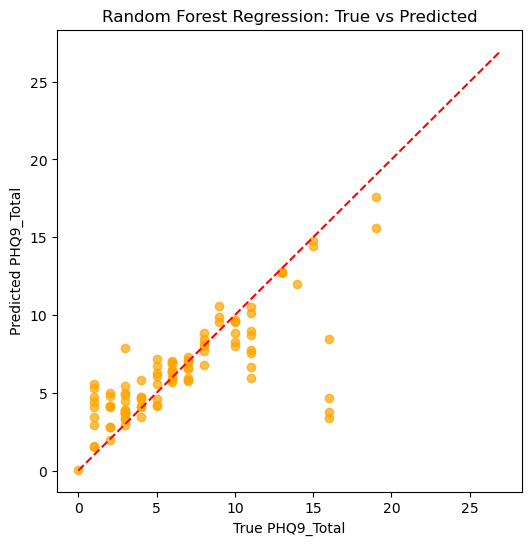

In [31]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test_reg, y_pred_rf_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)
print("Random Forest Regression MSE:", mse_rf)
print("Random Forest Regression R2:", r2_rf)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.7, color='orange')
plt.plot([0,27],[0,27], 'r--')  # y=x line
plt.xlabel("True PHQ9_Total")
plt.ylabel("Predicted PHQ9_Total")
plt.title("Random Forest Regression: True vs Predicted")
plt.show()

## Unsupervised Learning

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
unsupervised_cols = [
    "Q1_Age",
    "Q4_DailyPhoneTime_num", "Q5_CheckFrequency_num", "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num", "Q8_StopUseAtNight_num", "Q10_SocialMediaTime_num",
    "Q11_PhoneDuringMeals_num", "Q12_PhoneDuringWorkClass_num", "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num", "Q15_UseWhenBored_num", "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num", "Q18_PhoneInBed_num", "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num", "Q21_WakeToCheckPhone_num", "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num", "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num", "Q26_ConcentrationProblems_num", "Q27_PhysicalPain_num",
    "Q28_CannotStandWithoutPhone_num", "Q29_ImpatientWithoutPhone_num",
    "Q30_PhoneOnMyMind_num", "Q31_WontGiveUpPhone_num", "Q32_ConstantChecking_num",
    "Q33_UseLongerThanIntended_B_num", "Q34_OthersSayTooMuchUse_num"
]

X_unsupervised = df[unsupervised_cols].fillna(0)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

### PCA

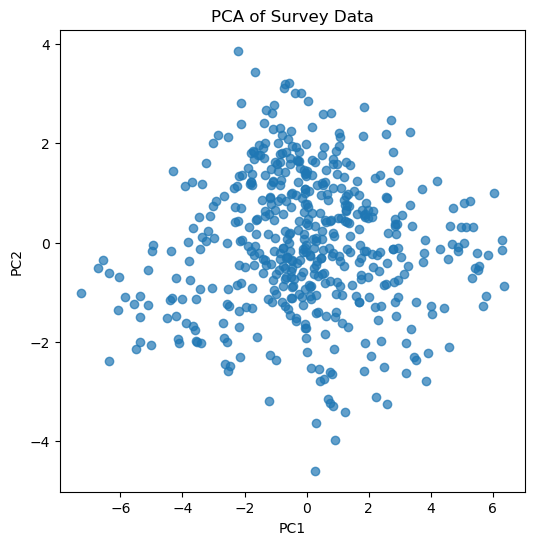

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Survey Data")
plt.show()

### K-means Clustering

c:\Users\User\miniconda3\envs\charllm-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


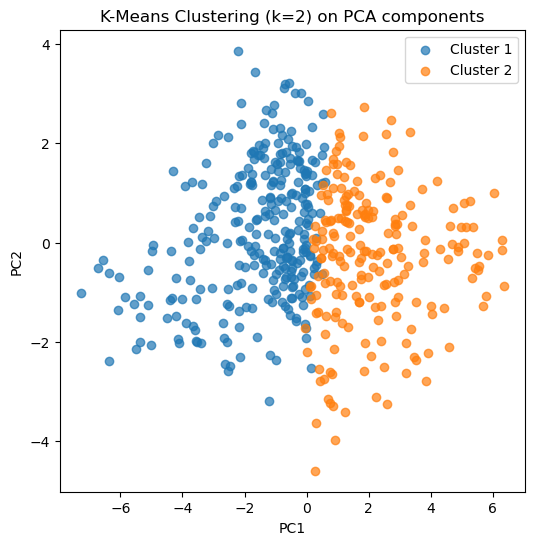

K=2 cluster PHQ9_Total averages:
Cluster
0    5.813793
1    8.766667
Name: PHQ9_Total, dtype: float64
----------------------------------------


c:\Users\User\miniconda3\envs\charllm-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


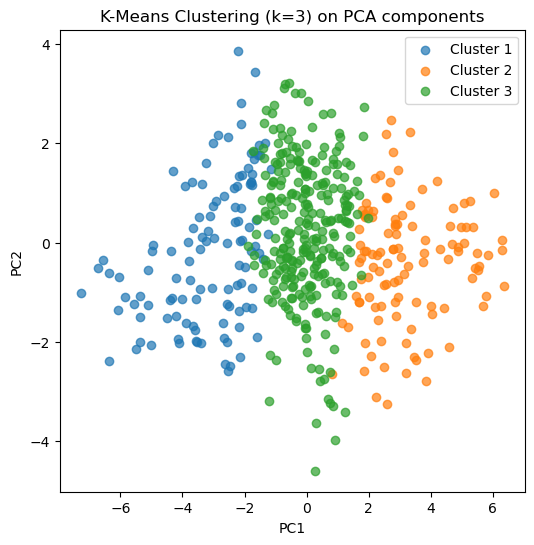

K=3 cluster PHQ9_Total averages:
Cluster
0    4.622807
1    9.548673
2    7.036630
Name: PHQ9_Total, dtype: float64
----------------------------------------


c:\Users\User\miniconda3\envs\charllm-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


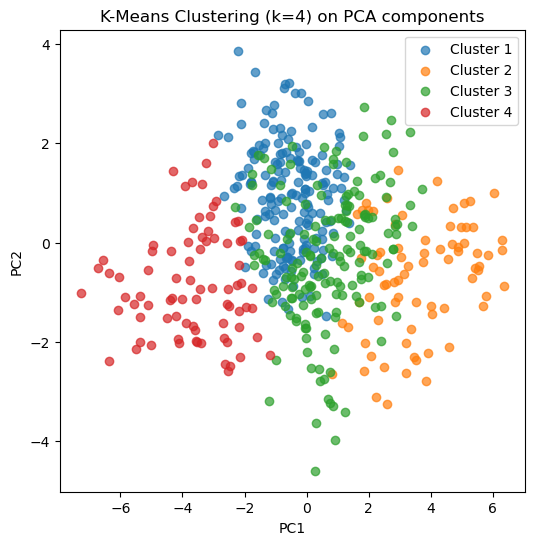

K=4 cluster PHQ9_Total averages:
Cluster
0    6.005556
1    9.415584
2    8.257669
3    4.687500
Name: PHQ9_Total, dtype: float64
----------------------------------------


In [42]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    # Scatter plot with clusters
    plt.figure(figsize=(6,6))
    for cluster in range(k):
        plt.scatter(
            X_pca[labels==cluster, 0],
            X_pca[labels==cluster, 1],
            alpha=0.7,
            label=f"Cluster {cluster+1}"
        )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"K-Means Clustering (k={k}) on PCA components")
    plt.legend()
    plt.show()
    
    # PHQ9_Total mean per cluster
    df["Cluster"] = labels
    cluster_phq_mean = df.groupby("Cluster")["PHQ9_Total"].mean()
    print(f"K={k} cluster PHQ9_Total averages:")
    print(cluster_phq_mean)
    print("-"*40)